C:\Users\Darshan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


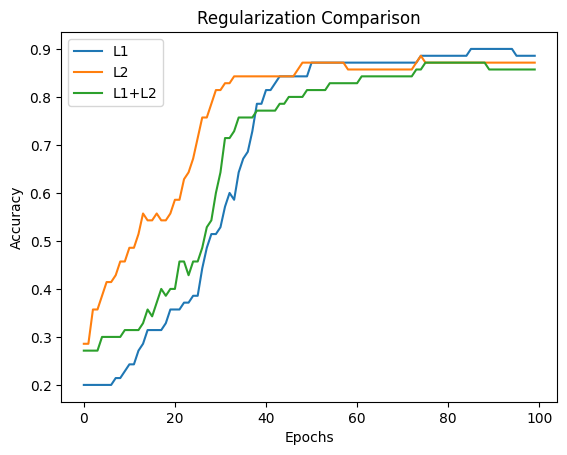

In [1]:
# Practical 5: Regularization (L1, L2, L1+L2)

from sklearn.datasets import make_moons
from keras.models import Sequential
from keras.layers import Dense
from keras.regularizers import l1, l2, l1_l2
import matplotlib.pyplot as plt

# 1. Create dataset
X, y = make_moons(n_samples=100, noise=0.2)

# 2. Split data
X_train, X_test = X[:30], X[30:]
y_train, y_test = y[:30], y[30:]

# 🔁 Function to build model (REUSABLE - easy to remember)
def build_model(reg):
    model = Sequential()
    model.add(Dense(50, input_dim=2, activation='relu', kernel_regularizer=reg))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# 3. Train models

# L1 Regularization
model_l1 = build_model(l1(0.001))
h1 = model_l1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=0)

# L2 Regularization
model_l2 = build_model(l2(0.001))
h2 = model_l2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=0)

# L1 + L2 Regularization
model_l12 = build_model(l1_l2(l1=0.001, l2=0.001))
h3 = model_l12.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=0)

# 4. Plot comparison
plt.plot(h1.history['val_accuracy'], label='L1')
plt.plot(h2.history['val_accuracy'], label='L2')
plt.plot(h3.history['val_accuracy'], label='L1+L2')

plt.title("Regularization Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()